PAREENITA A.SHIRSATH B.E.A.I.&.D.S.  ROLL.NO:49

AIFBA EXPERIMENT: 10

/tmp/ipykernel_1083/1385298366.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Total Return: 28.08%
Annual Return: 6.40%
Sharpe Ratio: 0.50
Sortino Ratio: 0.37
Max Drawdown: -17.15%
Win Rate: 50.00%
Profit Factor: 1.19

Best Parameters (Short MA, Long MA): (50, 200)


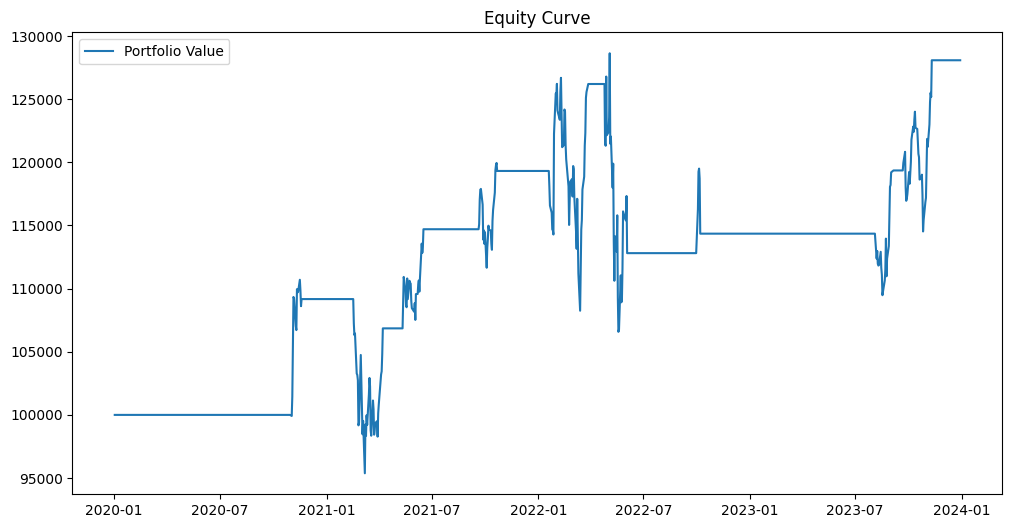

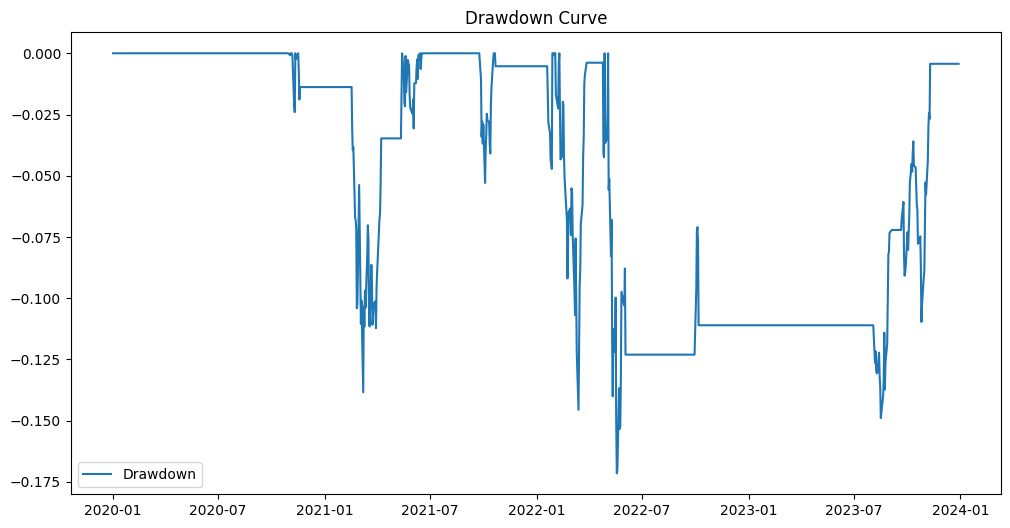

In [2]:
# ==========================================
# STEP 1: Install & Import Libraries
# ==========================================
!pip install yfinance pandas numpy matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 2: Load Data
# ==========================================
data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# ==========================================
# STEP 3: RSI Function
# ==========================================
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# ==========================================
# STEP 4: Strategy Function
# ==========================================
def backtest_strategy(data, short_ma=50, long_ma=200, rsi_period=14):

    df = data.copy()

    # Flatten MultiIndex columns if they exist (common for yfinance output)
    if isinstance(df.columns, pd.MultiIndex):
        # Assuming the format ('Metric', 'Ticker'), e.g., ('Close', 'AAPL')
        # Drop the second level (Ticker) to get simple column names like 'Close'
        df.columns = df.columns.droplevel(1)

    # Indicators
    df['MA_short'] = df['Close'].rolling(short_ma).mean()
    df['MA_long'] = df['Close'].rolling(long_ma).mean()
    df['RSI'] = compute_rsi(df['Close'], rsi_period)

    # Signals
    df['Signal'] = 0
    df.loc[(df['MA_short'] > df['MA_long']) & (df['RSI'] < 30), 'Signal'] = 1
    df.loc[(df['MA_short'] < df['MA_long']) | (df['RSI'] > 70), 'Signal'] = -1

    # Backtesting
    capital = 100000
    position = 0
    portfolio = []
    trades = []

    for i in range(len(df)):
        price = df['Close'].iloc[i]
        signal = df['Signal'].iloc[i]

        # Buy
        if signal == 1 and capital > 0:
            position = capital / price
            capital = 0
            trades.append(('Buy', price))

        # Sell
        elif signal == -1 and position > 0:
            capital = position * price
            position = 0
            trades.append(('Sell', price))

        total = capital + position * price
        portfolio.append(total)

    df['Portfolio'] = portfolio
    df['Returns'] = df['Portfolio'].pct_change()

    return df, trades

# ==========================================
# STEP 5: Run Strategy
# ==========================================
df, trades = backtest_strategy(data)

# ==========================================
# STEP 6: Performance Metrics
# ==========================================

initial_capital = 100000
final_value = df['Portfolio'].iloc[-1]

# Total Return
total_return = (final_value / initial_capital - 1) * 100

# Annualized Return
days = len(df)
annual_return = ((final_value / initial_capital) ** (252/days) - 1) * 100

# Sharpe Ratio
sharpe = (df['Returns'].mean() / df['Returns'].std()) * np.sqrt(252)

# Sortino Ratio
downside = df[df['Returns'] < 0]['Returns']
sortino = (df['Returns'].mean() / downside.std()) * np.sqrt(252)

# Max Drawdown
roll_max = df['Portfolio'].cummax()
drawdown = df['Portfolio'] / roll_max - 1
max_dd = drawdown.min() * 100

# Win Rate
profits = [t for t in trades if t[0] == 'Sell']
win_rate = len(profits) / len(trades) * 100 if trades else 0

# Profit Factor (simplified)
gains = df[df['Returns'] > 0]['Returns'].sum()
losses = abs(df[df['Returns'] < 0]['Returns'].sum())
profit_factor = gains / losses if losses != 0 else 0

# ==========================================
# STEP 7: Print Results
# ==========================================
print(f"Total Return: {total_return:.2f}%")
print(f"Annual Return: {annual_return:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Sortino Ratio: {sortino:.2f}")
print(f"Max Drawdown: {max_dd:.2f}%")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")

# ==========================================
# STEP 8: Parameter Optimization (Grid Search)
# ==========================================
best_return = -np.inf
best_params = None

for short in [20, 50, 100]:
    for long in [100, 150, 200]:
        df_test, _ = backtest_strategy(data, short, long)
        ret = df_test['Portfolio'].iloc[-1]

        if ret > best_return:
            best_return = ret
            best_params = (short, long)

print("\nBest Parameters (Short MA, Long MA):", best_params)

# ==========================================
# STEP 9: Visualization
# ==========================================

plt.figure(figsize=(12,6))
plt.plot(df['Portfolio'], label='Portfolio Value')
plt.title("Equity Curve")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(drawdown, label='Drawdown')
plt.title("Drawdown Curve")
plt.legend()
plt.show()